Convolutional Neural Networks (CNNs) are widely used for image classification tasks due to their ability to identify spatial patterns such as edges, textures, and anatomical structures [1].

In this notebook, a CNN is developed using PyTorch to classify chest X-ray images from the PneumoniaMNIST dataset. The dataset contains labeled chest X-ray images representing either normal lungs or pneumonia cases. The data are divided into training, validation, and test sets to train the model, optimize its performance, and evaluate its ability to classify previously unseen images. The complete workflow includes data preprocessing, model development, training, validation, and final performance evaluation [2].

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 115.9/115.9 kB 6.3 MB/s eta 0:00:00
cuda


100%|██████████| 4.17M/4.17M [00:06<00:00, 683kB/s]


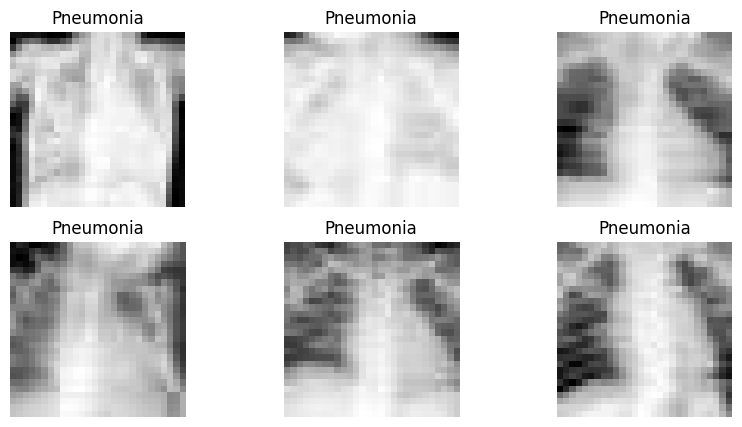

Epoch 1/10
Training Loss: 0.4217
Validation Loss: 0.2180


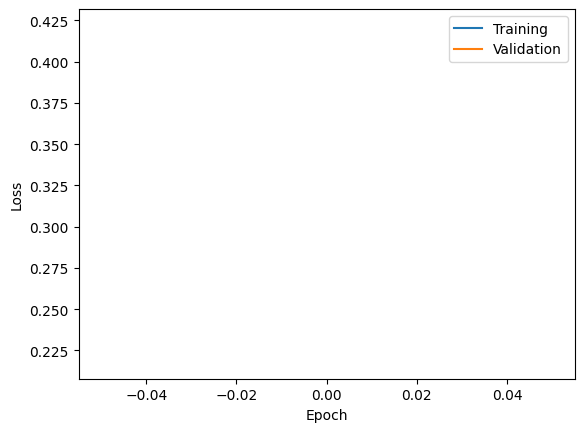

Epoch 2/10
Training Loss: 0.2087
Validation Loss: 0.1489


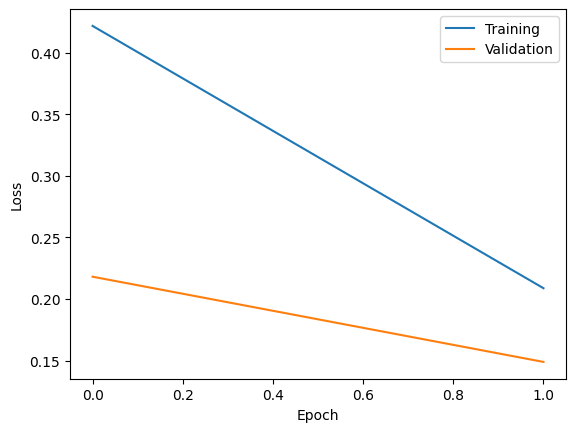

Epoch 3/10
Training Loss: 0.1872
Validation Loss: 0.1290


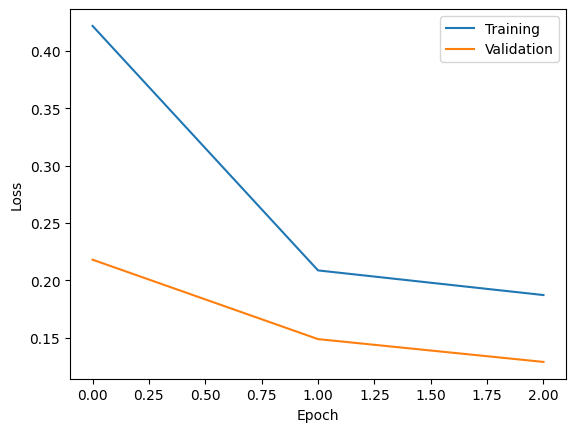

Epoch 4/10
Training Loss: 0.1660
Validation Loss: 0.1222


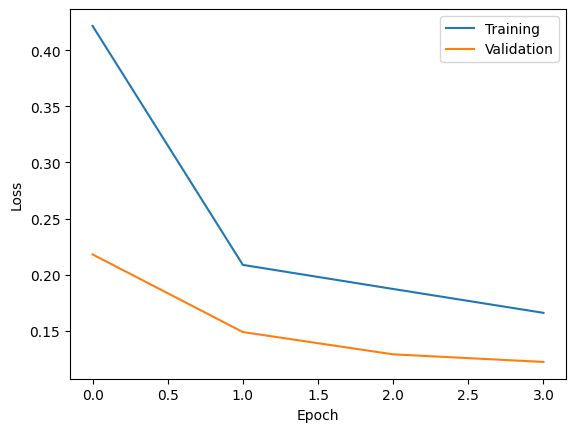

Epoch 5/10
Training Loss: 0.1600
Validation Loss: 0.1266


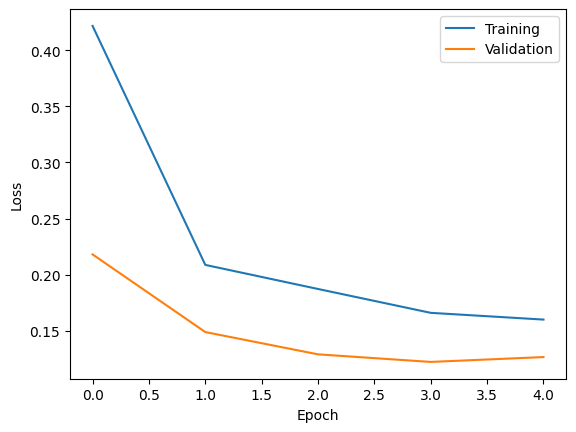

Epoch 6/10
Training Loss: 0.1417
Validation Loss: 0.1035


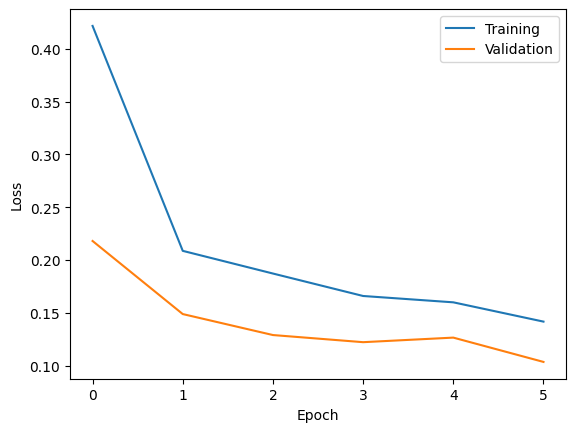

Epoch 7/10
Training Loss: 0.1447
Validation Loss: 0.1078


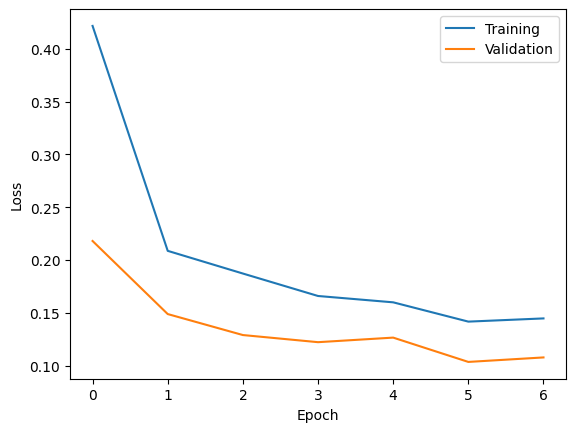

Epoch 8/10
Training Loss: 0.1325
Validation Loss: 0.0988


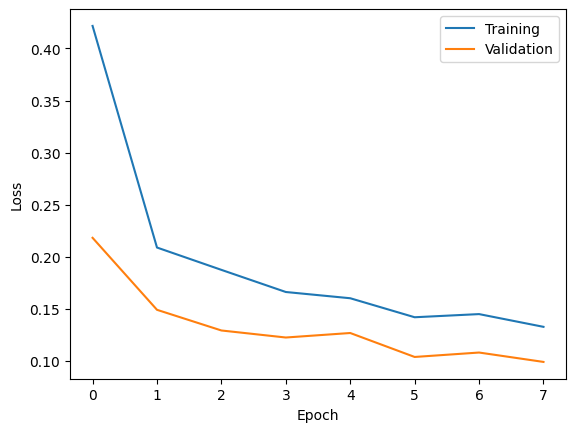

Epoch 9/10
Training Loss: 0.1353
Validation Loss: 0.1322


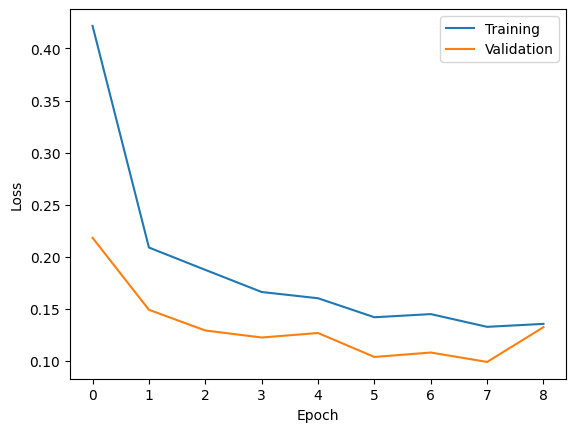

Epoch 10/10
Training Loss: 0.1304
Validation Loss: 0.0957


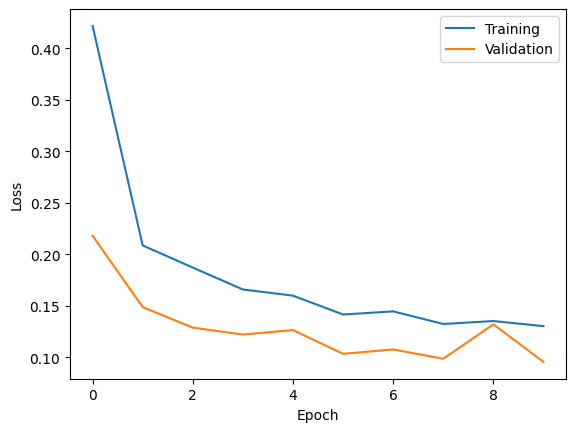

Test Accuracy: 85.58%


In [ ]:
!pip install medmnist

# Import libraries:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms

from torch.utils.data import DataLoader
from medmnist import PneumoniaMNIST

import matplotlib.pyplot as plt

# Configure the computing device:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

# Load and preprocess the dataset:
transform = transforms.Compose([transforms.ToTensor(),
                                transforms.Normalize((0.5,), (0.5,))])

train_dataset = PneumoniaMNIST(split='train', transform=transform, download=True)

val_dataset = PneumoniaMNIST(split='val',transform=transform, download=True)

test_dataset = PneumoniaMNIST( split='test', transform=transform, download=True)

batch_size = 128

# Create DataLoaders:
train_loader = DataLoader(train_dataset,batch_size=batch_size, shuffle=True)

val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False)

test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

# Visualize sample images:
images, labels = next(iter(train_loader))

plt.figure(figsize=(10,5))

for i in range(6):
    plt.subplot(2,3,i+1)
    plt.imshow(images[i].squeeze(), cmap='gray')
    plt.title("Pneumonia" if labels[i] else "Normal")
    plt.axis("off")

plt.show()

# Build the Convolutional Neural Network (CNN):
class CNN(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv = nn.Sequential(nn.Conv2d(1,16,3,padding=1),
                                  nn.ReLU(),
                                  nn.MaxPool2d(2),
                                  nn.Conv2d(16,32,3,padding=1),
                                  nn.ReLU(),
                                  nn.MaxPool2d(2))

        self.fc = nn.Sequential(nn.Flatten(),
                                nn.Linear(32*7*7,128),
                                nn.ReLU(),
                                nn.Dropout(0.3),
                                nn.Linear(128,2))

    def forward(self,x):
      x=self.conv(x)
      x=self.fc(x)
      return x

# Initialize the CNN model:
model = CNN().to(device)

criterion = nn.CrossEntropyLoss()

optimizer = optim.Adam(model.parameters(),lr=0.001)

epochs = 10

train_losses = []
val_losses = []

# Train and validate the model:
for epoch in range(epochs):
  model.train()
  running_loss = 0

  for images, labels in train_loader:
    images = images.to(device)
    labels = labels.squeeze().long().to(device)
    optimizer.zero_grad()
    outputs = model(images)
    loss = criterion(outputs,labels)
    loss.backward()
    optimizer.step()
    running_loss += loss.item()

  train_loss = running_loss/len(train_loader)
  train_losses.append(train_loss)
  model.eval()
  running_loss = 0

  with torch.no_grad():
    for images,labels in val_loader:
      images = images.to(device)
      labels = labels.squeeze().long().to(device)
      outputs = model(images)
      loss = criterion(outputs,labels)
      running_loss += loss.item()

    val_loss = running_loss/len(val_loader)
    val_losses.append(val_loss)

    print(f"Epoch {epoch+1}/{epochs}")
    print(f"Training Loss: {train_loss:.4f}")
    print(f"Validation Loss: {val_loss:.4f}")

# Visualize the training performance:
    plt.plot(train_losses,label="Training")
    plt.plot(val_losses,label="Validation")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.legend()
    plt.show()

# Evaluate the model on the test set:
correct = 0
total = 0

model.eval()

with torch.no_grad():
    for images, labels in test_loader:
        images = images.to(device)
        labels = labels.squeeze().long().to(device)
        outputs = model(images)
        _, predicted = torch.max(outputs, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

accuracy = 100 * correct / total
print(f"Test Accuracy: {accuracy:.2f}%")

**Results**

The CNN model achieved a test accuracy of 84.46% on the PneumoniaMNIST dataset. This result indicates that the model was able to learn meaningful image features associated with pneumonia and distinguish them from normal chest X-rays.

**References**

1. Yamashita, R., Nishio, M., Do, R. K. G., & Togashi, K. (2018). Convolutional neural networks: an overview and application in radiology. Insights into imaging, 9(4), 611–629. https://doi.org/10.1007/s13244-018-0639-9

2. Red neuronal convolucional (CNN). (n.d.). TensorFlow. https://www.tensorflow.org/tutorials/images/cnn?hl=es-419